# Health Disclosure Detection Model

Fine-tuning DistilRoBERTa to detect personal health disclosures.


## Install libraries


In [1]:
%pip install -q torch==2.7.1 transformers==4.44.2 datasets==2.21.0 accelerate==0.34.2 pandas scikit-learn matplotlib seaborn



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: /Users/shabbeermohammed/Desktop/CODE/Projects/AEGIS-hack36/.venv-ml/bin/python -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


## Import libraries


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    pipeline,
    set_seed,
)

SEED = 42
MODEL_NAME = "distilroberta-base"
MAX_LENGTH = 256
set_seed(SEED)


/Users/shabbeermohammed/Desktop/CODE/Projects/AEGIS-hack36/.venv-ml/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load dataset


In [3]:
file_name = "health_disclosure_dataset.csv"
possible_paths = [
    Path("data") / file_name,
    Path("backend/ml_service/notebooks/data") / file_name,
]

data_path = next((path for path in possible_paths if path.exists()), None)
if data_path is None:
    raise FileNotFoundError(f"Could not find {file_name}")

df = pd.read_csv(data_path)
df.head()


,text,label,category
0,I was diagnosed with type 2 diabetes during my...,1,diagnosis
1,My doctor confirmed that I have bronchial asthma.,1,diagnosis
2,I have been living with rheumatoid arthritis f...,1,diagnosis
3,The specialist diagnosed me with chronic kidne...,1,diagnosis
4,I was told that I have an underactive thyroid.,1,diagnosis


## Check dataset


Dataset shape: (400, 3)
Duplicate texts: 0
label
0    200
1    200
Name: count, dtype: int64


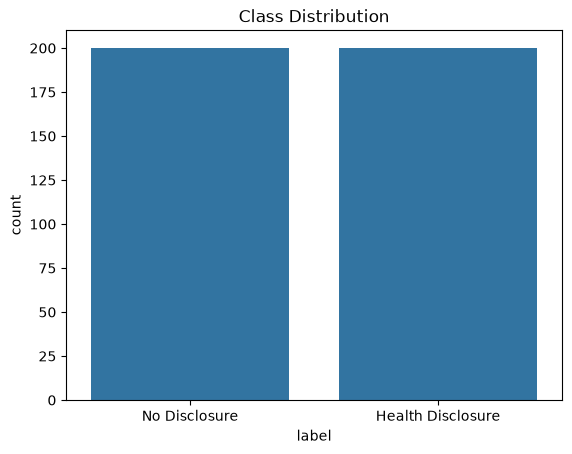

In [4]:
print("Dataset shape:", df.shape)
print("Duplicate texts:", df["text"].str.lower().duplicated().sum())
print(df["label"].value_counts().sort_index())

sns.countplot(data=df, x="label")
plt.xticks([0, 1], ["No Disclosure", "Health Disclosure"])
plt.title("Class Distribution")
plt.show()


## Split dataset


In [5]:
model_data = df[["text", "label"]]

train_df, temp_df = train_test_split(
    model_data,
    test_size=0.30,
    random_state=SEED,
    stratify=model_data["label"],
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["label"],
)

print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Test samples:", len(test_df))


Training samples: 280
Validation samples: 60
Test samples: 60


## Load tokenizer and model


In [6]:
id2label = {0: "NO_HEALTH_DISCLOSURE", 1: "HEALTH_DISCLOSURE"}
label2id = {"NO_HEALTH_DISCLOSURE": 0, "HEALTH_DISCLOSURE": 1}

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=id2label,
    label2id=label2id,
)


/Users/shabbeermohammed/Desktop/CODE/Projects/AEGIS-hack36/.venv-ml/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Tokenize dataset


In [7]:
def tokenize_data(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH,
    )

train_dataset = Dataset.from_pandas(train_df, preserve_index=False)
val_dataset = Dataset.from_pandas(val_df, preserve_index=False)
test_dataset = Dataset.from_pandas(test_df, preserve_index=False)

train_dataset = train_dataset.map(tokenize_data, batched=True)
val_dataset = val_dataset.map(tokenize_data, batched=True)
test_dataset = test_dataset.map(tokenize_data, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


Map:   0%|          | 0/280 [00:00<?, ? examples/s]

Map: 100%|██████████| 280/280 [00:00<00:00, 24602.08 examples/s]

Map:   0%|          | 0/60 [00:00<?, ? examples/s]

Map: 100%|██████████| 60/60 [00:00<00:00, 18414.92 examples/s]

Map:   0%|          | 0/60 [00:00<?, ? examples/s]

Map: 100%|██████████| 60/60 [00:00<00:00, 19016.04 examples/s]

## Evaluation metrics


In [8]:
def compute_metrics(eval_prediction):
    logits, labels = eval_prediction
    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average="binary", zero_division=0
    )

    return {
        "accuracy": accuracy_score(labels, predictions),
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


## Train model


In [9]:
training_args = TrainingArguments(
    output_dir="./disease_training_output",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=10,
    weight_decay=0.01,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    save_total_limit=2,
    report_to="none",
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer.train()


/Users/shabbeermohammed/Desktop/CODE/Projects/AEGIS-hack36/.venv-ml/lib/python3.11/site-packages/transformers/training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


/Users/shabbeermohammed/Desktop/CODE/Projects/AEGIS-hack36/.venv-ml/lib/python3.11/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.550900,0.096695,1.000000,1.000000,1.000000,1.000000
2,0.072200,0.000742,1.000000,1.000000,1.000000,1.000000
3,0.001000,0.000311,1.000000,1.000000,1.000000,1.000000


/Users/shabbeermohammed/Desktop/CODE/Projects/AEGIS-hack36/.venv-ml/lib/python3.11/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


/Users/shabbeermohammed/Desktop/CODE/Projects/AEGIS-hack36/.venv-ml/lib/python3.11/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


TrainOutput(global_step=105, training_loss=0.2080185008900506, metrics={'train_runtime': 25.4317, 'train_samples_per_second': 110.099, 'train_steps_per_second': 13.762, 'total_flos': 3363430044000.0, 'train_loss': 0.2080185008900506, 'epoch': 3.0})

## Training history


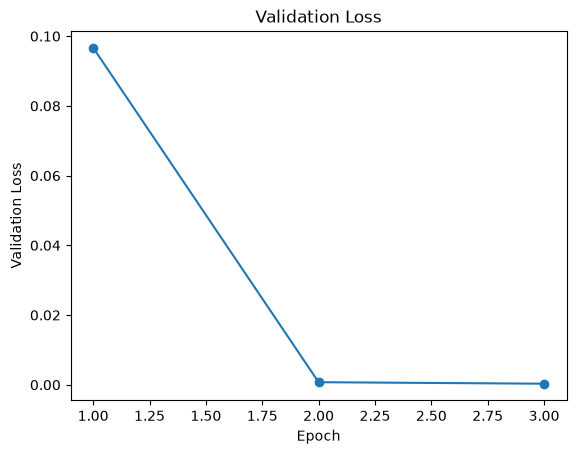

Best checkpoint: ./disease_training_output/checkpoint-35
Best validation F1: 1.0


In [10]:
history = pd.DataFrame(trainer.state.log_history)
eval_history = history.dropna(subset=["eval_loss"])

plt.plot(eval_history["epoch"], eval_history["eval_loss"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss")
plt.show()

print("Best checkpoint:", trainer.state.best_model_checkpoint)
print("Best validation F1:", trainer.state.best_metric)


## Evaluate on test data


/Users/shabbeermohammed/Desktop/CODE/Projects/AEGIS-hack36/.venv-ml/lib/python3.11/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'eval_loss': 0.22801430523395538, 'eval_accuracy': 0.9333333333333333, 'eval_precision': 0.8823529411764706, 'eval_recall': 1.0, 'eval_f1': 0.9375, 'eval_runtime': 0.1676, 'eval_samples_per_second': 357.907, 'eval_steps_per_second': 47.721, 'epoch': 3.0}


/Users/shabbeermohammed/Desktop/CODE/Projects/AEGIS-hack36/.venv-ml/lib/python3.11/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


                      precision    recall  f1-score   support

No Health Disclosure       1.00      0.87      0.93        30
   Health Disclosure       0.88      1.00      0.94        30

            accuracy                           0.93        60
           macro avg       0.94      0.93      0.93        60
        weighted avg       0.94      0.93      0.93        60



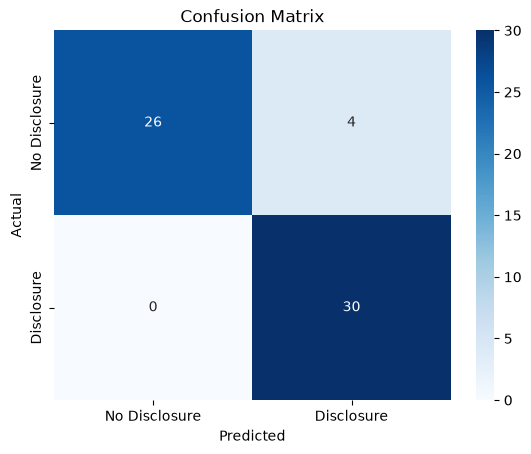

In [11]:
test_results = trainer.evaluate(test_dataset)
print(test_results)

test_predictions = trainer.predict(test_dataset)
y_pred = np.argmax(test_predictions.predictions, axis=-1)
y_true = test_predictions.label_ids

print(classification_report(
    y_true,
    y_pred,
    target_names=["No Health Disclosure", "Health Disclosure"],
))

matrix = confusion_matrix(y_true, y_pred)
sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disclosure", "Disclosure"],
    yticklabels=["No Disclosure", "Disclosure"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


## Save model


In [12]:
MODEL_PATH = "./disease_model_v2"
trainer.save_model(MODEL_PATH)
tokenizer.save_pretrained(MODEL_PATH)
print("Model saved to:", MODEL_PATH)


Model saved to: ./disease_model_v2


## Try some examples


In [13]:
classifier = pipeline(
    "text-classification",
    model=MODEL_PATH,
    tokenizer=MODEL_PATH,
)

examples = [
    "I was diagnosed with asthma last year.",
    "My latest blood test was normal.",
    "How does insulin help people with diabetes?",
    "A university published research about cancer screening.",
]

for text in examples:
    result = classifier(text)[0]
    print(text)
    print(result)
    print()


Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


I was diagnosed with asthma last year.
{'label': 'HEALTH_DISCLOSURE', 'score': 0.9701281785964966}

My latest blood test was normal.
{'label': 'HEALTH_DISCLOSURE', 'score': 0.9735280871391296}

How does insulin help people with diabetes?
{'label': 'NO_HEALTH_DISCLOSURE', 'score': 0.8975735902786255}

A university published research about cancer screening.
{'label': 'NO_HEALTH_DISCLOSURE', 'score': 0.9026613831520081}

